# Week 11 Problem Set


In [ ]:
%load_ext nb_mypy
%nb_mypy On

In [2]:
from typing import TypeAlias
from typing import Optional, Any    

Number: TypeAlias = int | float

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.axes as axes
from IPython.display import display


## Cohort Session

**CS0.** Do the following tasks before you start with the first cohort session.

**Task 1.** Paste the following functions from your previous work:
- `get_features_targets()`
- `normalize_z()`
- `prepare_feature()`
- `prepare_target()`
- `split_data()`


In [4]:
def normalize_z(array: np.ndarray, columns_means: Optional[np.ndarray]=None, 
                columns_stds: Optional[np.ndarray]=None) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    assert columns_means is None or columns_means.shape == (1, array.shape[1])
    assert columns_stds is None or columns_stds.shape == (1, array.shape[1])
    if columns_means is None:
        columns_means = array.mean(axis=0).reshape(1,-1)
    if columns_stds is None:
        columns_stds = array.std(axis=0).reshape(1,-1)
    out: np.ndarray = (array - columns_means) / columns_stds
    assert out.shape == array.shape
    assert columns_means.shape == (1, array.shape[1])
    assert columns_stds.shape == (1, array.shape[1])
    return out, columns_means, columns_stds

def get_features_targets(df: pd.DataFrame, 
                         feature_names: list[str], 
                         target_names: list[str]) -> tuple[pd.DataFrame, pd.DataFrame]:
    ### BEGIN SOLUTION
    df_feature: pd.DataFrame = df[feature_names]
    df_target: pd.DataFrame = df[target_names]
    ### END SOLUTION
    pass
    return df_feature, df_target

def prepare_feature(np_feature: np.ndarray) -> np.ndarray:
    ### BEGIN SOLUTION
    # cols = len(df_feature.columns)
    cols: int = np_feature.shape[1]
    X: np.ndarray = np.concatenate((np.ones((np_feature.shape[0],1)), np_feature), axis=1)
    return X
    ### END SOLUTION
    pass

def split_data(df_feature: pd.DataFrame, 
               df_target: pd.DataFrame, 
               random_state: Optional[Number]=None, 
               test_size: float=0.5) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    ### BEGIN SOLUTION
    indexes: pd.Index = df_feature.index
    if random_state is not None:
        np.random.seed(random_state)
    k: int = int(test_size * len(indexes))
    test_index: pd.Index = np.random.choice(indexes, k, replace=False)
    train_index: pd.Index = indexes.drop(test_index) 
    df_feature_train: pd.DataFrame = df_feature.loc[train_index, :]
    df_feature_test: pd.DataFrame = df_feature.loc[test_index, :]
    df_target_train: pd.DataFrame = df_target.loc[train_index, :]
    df_target_test: pd.DataFrame = df_target.loc[test_index, :]
    ### END SOLUTION
    return df_feature_train, df_feature_test, df_target_train, df_target_test
 

**Task 2.** Load the breast cancer data from `breast_cancer_data.csv` into a Data Frame. 

In [5]:
# read breast_cancer_data.csv
# df: pd.DataFrame = None

### BEGIN SOLUTION
### END SOLUTION

df: pd.DataFrame = pd.read_csv('./breast_cancer_data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


**Task 3.** Do the following tasks.

- Read the following columns
    - feature: `radius_mean`
    - target: `diagnosis`
- Normalize the feature column using z normalization.

In [6]:
# extract the feature and the target
df_feature, df_target = get_features_targets(df, ["radius_mean"], ["diagnosis"])
 
# normalize the feature
# the test set is supposed to be z-normalized using train-set mean and stdev only 
# by right: we need to split first, then normalize_z the train-set, and then call normalize_z the test-set again with train-set mean and stdev 
# when we use the model (actual usage, not test), we only have 1 current usage point, so we need to normalize_z that with train-set mean and stdev 
array_feature,_,_ = normalize_z(df_feature.to_numpy()) 


**Task 4.** Write a function `replace_target()` to replace the `diagnosis` column with the following mapping:
    - `M`: `1`, this means that malignant cell are indicated as `1` in our new column.
    - `B`: `0`, this means that benign cell are indicated as `0` in our new column.
    
The function should takes in the following:

- `df_target`: the target data frame
- `target_name`: which is the column name of the target data frame
- `map`: which is a dictionary containing the map
    
It should returns a new data frame with the same column name but with its values changed according to the mapping.

In [7]:
def replace_diagnosis_column(x):
    diagnosis = {'M': 1, 'B': 0}
    return diagnosis[x]

def replace_target(df_target: pd.DataFrame, 
                   target_name: str, map_vals: dict[Any, Any]) -> pd.DataFrame:

     # make a copy of the target df
     df_out: pd.DataFrame = df_target.copy() 
     # df_out.loc[:, target_name]: for all rows with column target_name, we replace it with a new column from the RHS 
     # the RHS: we take the column with target name via df_target[target_name] and run the function 
     # lambda x: map_vals[x] 
     # def replace(x): return map_vals[x]
     # pandas take all elements in target_name column, an for each element in target_name column, it will be the argument x to the lambda function, and be replaced by map_vals[x]
     # equivalent to the following:
     #  df_out.loc[:, target_name] = df_target[target_name].apply(replace_diagnosis_column)
     df_out.loc[:, target_name] = df_target[target_name].apply(lambda x: map_vals[x])
     return df_out

In [8]:
df_target: pd.DataFrame = replace_target(df_target, "diagnosis", {'M': 1, 'B': 0})
df_target

,diagnosis
0,1
1,1
2,1
3,1
4,1
...,...
564,1
565,1
566,1
567,1


**Task 5.** Do the following tasks.
- Change feature to Numpy array and append constant 1 column.
- Change target to Numpy array

In [9]:
# change feature data frame to numpy array and append column 1
# create the feature X matrix
feature: np.ndarray = prepare_feature(array_feature) 

# change target data frame to numpy array
target: np.ndarray = df_target.to_numpy()



**CS1.** *Logistic function:* Write a function to calculate the hypothesis using a logistic function. Recall that the hypothesis for a logistic regression model is written as:

$$\mathbf{p}(x) = \frac{1}{1 + e^{-\mathbf{X}\mathbf{b}}}$$

The shape of the input is as follows:
- $\mathbf{b}$: is a column vector for the parameters
- $\mathbf{X}$: is a matrix where the number of rows are the number of data points and the the number of columns must the same as the number of parameters in $\mathbf{b}$.

Note that you need to ensure that the output is a **column vector**. 

You can use the following functions:
- `np.matmul(array1, array2)`: which is to perform matrix multiplication on the two numpy arrays.
- `np.exp()`: which is to calculate the function $e^x$

In [10]:
def calc_logreg(X: np.ndarray, beta: np.ndarray) -> np.ndarray:
   X = X.astype(float)
   beta = beta.astype(float)
   # this function returns p(x)
   return 1.0/(1.0 + np.exp(np.matmul(X, -beta)))
 

In [11]:
beta: np.ndarray = np.array([0])
x: np.ndarray = np.array([0])
ans: np.ndarray = calc_logreg(x, beta)
assert ans == 0.5

beta: np.ndarray  = np.array([2])
x: np.ndarray  = np.array([40])
ans: np.ndarray  = calc_logreg(x, beta)
assert np.isclose(ans, 1.0)

beta: np.ndarray  = np.array([2])
x: np.ndarray  = np.array([-40])
ans: np.ndarray  = calc_logreg(x, beta)
assert np.isclose(ans, 0.0)

beta: np.ndarray  = np.array([[1, 2, 3]])
x: np.ndarray  = np.array([[3, 2, 1]])
ans: np.ndarray  = calc_logreg(x, beta.T)
assert np.isclose(ans.all(), 1.0)

beta: np.ndarray  = np.array([[1, 2, 3]])
x: np.ndarray  = np.array([[3, 2, 1], [3, 2, 1]])
ans: np.ndarray  = calc_logreg(x, beta.T)
assert ans.shape == (2, 1)
assert np.isclose(ans.all(), 1.0)

**CS2.** *Cost Function:* Write a function to calculate the cost function for logistic regression. Recall that the cost function for logistic regression is given by:

$$J(\beta) = -\frac{1}{m}\left[\Sigma_{i=1}^m y^i \log(p(x^i)) + (1 - y^i) \log(1 - p(x^i))\right]$$

You can use the following function in your code:
- `np.where(condition, then_expression, else_expression)`

In [12]:
def compute_cost_logreg(X: np.ndarray, 
                        y: np.ndarray,
                        beta: np.ndarray) -> Number:
    # compute the number of datapoints
    m: int = len(y)
    # np.where returns a vector of all sample likelihood, an m by 1 vector
    J: Number = -1/m * np.sum(
        np.where(y==1, np.log(calc_logreg(X, beta)), np.log(1-calc_logreg(X,beta)))
    ) 
    # if you want to do things naively 
    # loop through every single element in y
    # J = 0
    # for i in range(len(y)):
    #     if y[i] is 1:
    #          J += np.squeeze(np.log(calc_logreg(X[i], beta)))
    #     else:
    #          J += 1 - np.squeeze(np.log(calc_logreg(X[i], beta)))
    # J *= -1/m
    return J

In [13]:
y: np.ndarray = np.array([[1]])
X: np.ndarray  = np.array([[10, 40]])
beta: np.ndarray  = np.array([[1, 1]]).T
ans: Number = compute_cost_logreg(X, y, beta)
print(ans)
assert np.isclose(ans, 0)

y: np.ndarray  = np.array([[0]])
X: np.ndarray  = np.array([[10, 40]])
beta: np.ndarray  = np.array([[-1, -1]]).T
ans: Number = compute_cost_logreg(X, y, beta)
print(ans)
assert np.isclose(ans, 0)

-0.0
-0.0


/var/folders/c7/tz8vsxx113l2m__tjdw9zd200000gn/T/ipykernel_40479/1693937531.py:8: RuntimeWarning: divide by zero encountered in log
  np.where(y==1, np.log(calc_logreg(X, beta)), np.log(1-calc_logreg(X,beta)))


**CS3.** *Gradient Descent:* Recall that the update functions can be written as a matrix multiplication.

$$\mathbf{b} = \mathbf{b} - \alpha\frac{1}{m}\mathbf{X}^T(\mathbf{p} - \mathbf{y}) $$

Write a function called `gradient_descent_logreg()` that takes in four parameters:
- `X`: is a 2-D numpy array for the features
- `y`: is a vector array for the target
- `beta`: is a column vector for the initial guess of the parameters
- `alpha`: is the learning rate
- `num_iters`: is the number of iteration to perform

The function should return two arrays:
- `beta`: is coefficient at the end of the iteration
- `J_storage`: is the array that stores the cost value at each iteration

The solution is similar to Linear Regression gradient descent function with two differences:
- you need to use `log_regression()` to calculate the hypothesis
- you need to use `compute_cost_logreg()` to calculate the cost

In [14]:
# it would be better if this function is a generic gradient descent function that receives TWO other function: deriv (to compute derivative) and cost function to store in J_storage
from  typing import Callable
def deriv_logreg(X: np.ndarray, y: np.ndarray, beta: np.ndarray) -> np.ndarray:
    return np.matmul(X.T, (calc_logreg(X, beta) - y)) 

# we can use this gradient_descent with any cost func and any deriv func that fits the interface specified
def gradient_descent(X: np.ndarray, 
                    y: np.ndarray, 
                    beta: np.ndarray, 
                    alpha: float,
                    num_iters: int,
                    deriv_func: Callable[[np.ndarray,np.ndarray,np.ndarray],np.ndarray],
                    cost_func:Callable[[np.ndarray,np.ndarray,np.ndarray],Number] ) -> tuple[np.ndarray, np.ndarray]:
    # find size of data points
    m: int = X.shape[0]
    # create an array to store error value J at each iteration
    # it is an num_iters of gd x 1 vector
    J_storage: np.ndarray = np.zeros((num_iters,1))
    for n in range(num_iters):
        # compute derivative of error with this current beta
        # don't forget that matmul here "loops" through ALL m datapoints in the train set
        deriv: np.ndarray = deriv_func(X, y, beta)
        # update the beta to be new beta
        beta = beta - alpha * (1/m) * deriv 
        # compute error value with this new beta
        J_storage[n] = cost_func(X, y, beta)

    assert beta.shape == (X.shape[1], 1) # beta is a column vector 
    assert J_storage.shape == (num_iters, 1) 
    return beta, J_storage 

def gradient_descent_logreg(X: np.ndarray, 
                            y: np.ndarray, 
                            beta: np.ndarray, 
                            alpha: float,
                            num_iters: int) -> tuple[np.ndarray, np.ndarray]:
    # find size of data points
    m: int = X.shape[0]
    # create an array to store error value J at each iteration
    # it is an num_iters of gd x 1 vector
    J_storage: np.ndarray = np.zeros((num_iters,1))
    for n in range(num_iters):
        # compute derivative of error with this current beta
        # don't forget that matmul here "loops" through ALL m datapoints in the train set
        deriv: np.ndarray =  np.matmul(X.T, (calc_logreg(X, beta) - y))
        # update the beta to be new beta
        beta = beta - alpha * (1/m) * deriv 
        # compute error value with this new beta
        J_storage[n] = compute_cost_logreg(X, y, beta)
        
    # change beta floats from python floats into numpy floats to so CS5 np.isclose can compare
    beta = np.array(beta, dtype=float)
    assert beta.shape == (X.shape[1], 1) # beta is a column vector 
    assert J_storage.shape == (num_iters, 1) 
    return beta, J_storage 
     

In [15]:
iterations: int = 1500
alpha: float = 0.01
beta: np.ndarray = np.zeros((2,1))
beta, J_storage = gradient_descent_logreg(feature, target, beta, alpha, iterations)

print(beta)
assert beta.shape == (2, 1)
assert np.isclose(beta[0][0], -0.56631, rtol=1e-3)
assert np.isclose(beta[1][0], 1.93742, rtol=1e-3)

[[-0.56630978]
 [ 1.93742212]]


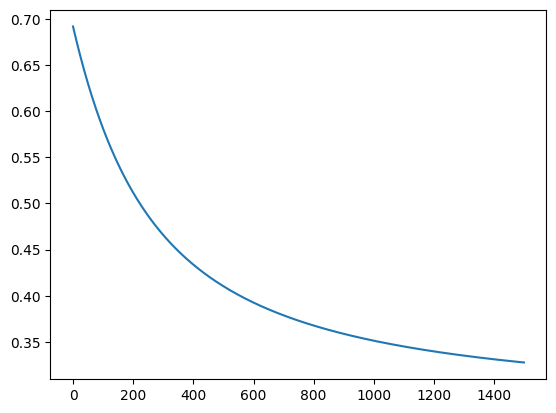

In [16]:
plt.plot(J_storage)

**CS4.** *Predict:* Write two functions `predict_logreg()` and `predict_norm()` that calculate the straight line equation given the features and its coefficient.
- `predict_logreg()`: this function should standardize the feature using z normalization, change it to a Numpy array, and add a column of constant 1s. You should use `prepare_feature()` for this purpose. Lastly, this function should also call `predict_norm()` to get the predicted y values.
- `predict_norm()`: this function should calculate the hypothesis or its probability using `calc_logreg()` and categorize it to either 0 or 1 based on its probability. If the probability is greater or equal to 0.5, it should be classified as class 1. Otherwise, it is classified as 0.

You can use the following function in your code:
- `np.where()`

In [17]:
def predict_norm(X: np.ndarray, beta: np.ndarray) -> np.ndarray:

    # p is a vector containing probability of ALL samples in the set defined by X 
    p: np.ndarray = calc_logreg(X, beta)
    # does np.where REPLACE the elements in p and modify p? NO
    # np.where CREATES a new array with the new elements and return it, it leaves p intact
    return np.where(p >= 0.5, 1, 0) # np.where will loop through all elements in p, and replace them with 1 or 0 and return as a new array


In [18]:
def predict_logreg(array_feature: np.ndarray, 
                   beta: np.ndarray, 
                   means: Optional[np.ndarray]=None, 
                   stds: Optional[np.ndarray]=None) -> np.ndarray:
    norm_data, _, _ = normalize_z(array_feature, means, stds)
    X: np.ndarray = prepare_feature(norm_data)
    result = predict_norm(X, beta)
    assert result.shape == (array_feature.shape[0], 1) # ensure that the result vector has m elements (and 1 col)
    return result 

In [19]:
df_feature, df_target = get_features_targets(df, ["radius_mean"], ["diagnosis"])
df_target: pd.DataFrame = replace_target(df_target, "diagnosis", {'M': 1, 'B': 0})
pred: np.ndarray = predict_logreg(df_feature.to_numpy(), beta)
print(pred.mean(), pred.std())
assert isinstance(pred, np.ndarray)
assert np.isclose(pred.mean(), 0.28998)
assert np.isclose(pred.std(), 0.45375)

0.28998242530755713 0.4537539182423709


In [20]:
means: np.ndarray = np.array([0]).reshape(1,1)
stds: np.ndarray = np.array([1]).reshape(1,1)
beta: np.ndarray =np.array([[-0.56630289], [ 1.93763591]])
input_1row: np.ndarray = np.array([[2.109139]])
pred_1row: np.ndarray = predict_logreg(input_1row, beta, means, stds)
assert pred_1row[0][0] == 1

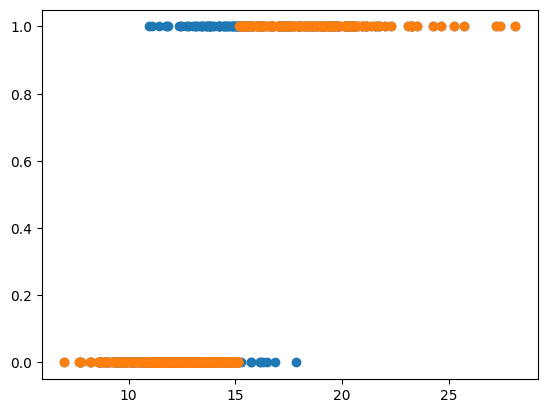

In [21]:
plt.scatter(df_feature, df_target)
plt.scatter(df_feature, pred)

**CS5.** *Multiple features and splitting of data set:* 

Do the following task in the code below:
- Read the following column names as the features: `"radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean"`
- Read the column `diagnosis` as the target. Change the value from `M` and `B` to `1` and `0` respectively.
- Split the data set with 30% test size and `random_state = 100`.
- Normalize the training feature data set using `normalize_z()` function.
- Convert to numpy array both the target and the features using `prepare_feature()` and `prepare_target()` functions.
- Call `gradient_descent()` function to get the parameters using the training data set.
- Call `predict()` function on the test data set to get the predicted values.

In [22]:
columns: list[str] = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean"]

# extract the features and the target columns
df_features, df_target = get_features_targets(df, columns, ["diagnosis"])
# replace the target values using from string to integer 0 and 1
df_target: pd.DataFrame = replace_target(df_target, "diagnosis", {'M': 1, 'B': 0}) # the one that is more IMPORTANT "malignant" will be the TRUE value, that is we are finding the parameters that explain the characteristics of malignant cell

# split the data with random_state = 100 and 30% test size
df_features_train, df_features_test, df_target_train, df_target_test = split_data(df_features, df_target, random_state = 100, test_size = 0.3)

# normalize the features of the TRAIN SET 
# and then get the means and stds (this must strictly come from TRAIN SET) 
# this will be used to normalize the features of the TEST SET and VALIDATION SET 
# YOU CANNOT take the means and stds of the entire SET (train + test) because this will leak "bleed" information out when we are testing the dataset. We are not supposed to "KNOW" the characteristics of the test set, including the means and the stdev
# this is why the TRAIN SET cannot be biased, it has to (hopefully) fairy capture the characteristics of the population of the dataset 
array_features_train_z, means, stds = normalize_z(df_features_train.to_numpy())

# change the feature columns to numpy array and append column of 1s
features: np.ndarray = prepare_feature(array_features_train_z) # this is the X matrix

# change the target column to numpy array
target: np.ndarray = df_target_train.to_numpy()

iterations: int = 1500
alpha: float = 0.01

# provide initial guess for beta
beta: np.ndarray = np.zeros((features.shape[1],1)) # create a n+1 by 1 vector 

# call the gradient descent method
beta, J_storage = gradient_descent_logreg(features, target, beta, alpha, iterations)

print(beta)





[[-0.6138507 ]
 [ 0.82491639]
 [ 0.72743625]
 [ 0.82325868]
 [ 0.81618797]
 [ 0.5057594 ]
 [ 0.44115946]
 [ 0.78701749]]


In [23]:
assert beta.shape == (8, 1)
ans: np.ndarray = np.array([[-0.6138507], 
                [ 0.8249164],
                [ 0.7274362],
                [ 0.8232587],
                [ 0.8161879],
                [ 0.5057594],
                [ 0.4411595],
                [ 0.7870175]])
assert np.isclose(beta, ans).all()

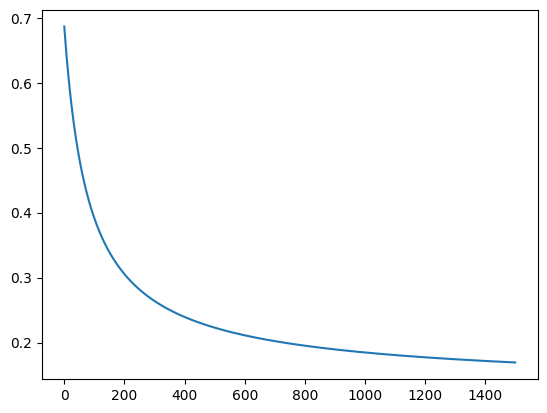

In [24]:
plt.plot(J_storage)

**CS6.** Create a function `build_model_logreg()` that perform the following steps:
- change all data to numpy array.
- normalize the training feature data set using `normalize_z()` function.
- create X matrix.
- use `reshape(-1, 1)` on the target array to make sure it is a column vector. 
- run gradient descent by calling `gradient_descent_logreg()` function.

This function should output `model` and `J_storage` where `model` is a dictionary containing `beta`, `means` and `stds`. 

In [25]:
def build_model_logreg(df_feature_train: pd.DataFrame,
                       df_target_train: pd.DataFrame,
                       beta: Optional[np.ndarray] = None,
                       alpha: float = 0.01,
                       iterations: int = 1500) -> tuple[dict[str, Any], np.ndarray]:
    if beta is None:
        beta = np.zeros((df_feature_train.shape[1]+1,1))
        
    model: dict[str, Any] = {}
    
    array_features_train_z, means, stds = normalize_z(df_feature_train.to_numpy())
    
    X: np.ndarray = prepare_feature(array_features_train_z) # this is the X matrix
    target: np.ndarray = df_target_train.to_numpy().reshape(-1,1) # make sure we have a single column for this target vector 
    beta, J_storage = gradient_descent_logreg(X, target, beta, alpha, iterations)
    
    model = {"beta": beta, "means": means, "stds": stds}

    return model, J_storage
    
         

In [26]:
columns = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean"]
df_features, df_target = get_features_targets(df, columns, ["diagnosis"])
df_target: pd.DataFrame = replace_target(df_target, "diagnosis", {'M': 1, 'B': 0})

df_features_train, df_features_test, df_target_train, df_target_test = split_data(df_features, df_target, random_state=100, test_size=0.3)
model, J_storage = build_model_logreg(df_features_train, df_target_train)

assert isinstance(model, dict)
assert "beta" in model
assert "means" in model
assert "stds" in model
assert model["beta"].shape == (8, 1)
ans: np.ndarray = np.array([[-0.6138507], 
                [ 0.8249164],
                [ 0.7274362],
                [ 0.8232587],
                [ 0.8161879],
                [ 0.5057594],
                [ 0.4411595],
                [ 0.7870175]])
assert np.isclose(model["beta"], ans).all()
assert np.isclose(model['means'][0, 0], 1.40347594e+01)
assert np.isclose(model['stds'][-1, -1], 7.54400405e-02)

In [27]:
###
### AUTOGRADER TEST - DO NOT REMOVE
###

In [28]:

# call predict() on one record to get the predicted values
# use the variable 'means' and 'stds' to normalize
input_1row: np.ndarray = np.array([[12.22, 20.04, 79.47, 453.1, 0.10960, 0.11520, 0.08175]])

# replace the None
# input_1row new data to test will be normalized with model means and model stds
pred_1row: np.ndarray = predict_logreg(input_1row, model["beta"], model["means"], model["stds"]) 


In [29]:
assert pred_1row[0][0] == 0

In [30]:
# call predict() on df_features test dataset to get the predicted values
pred: np.ndarray = predict_logreg(df_features_test.to_numpy(),  model["beta"], model["means"], model["stds"]) 



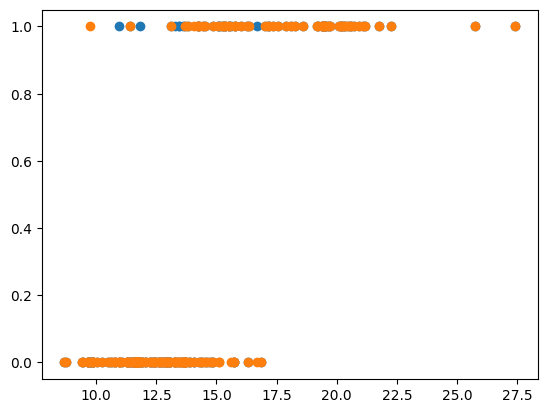

In [31]:
plt.scatter(df_features_test["radius_mean"], df_target_test)
plt.scatter(df_features_test["radius_mean"], pred)

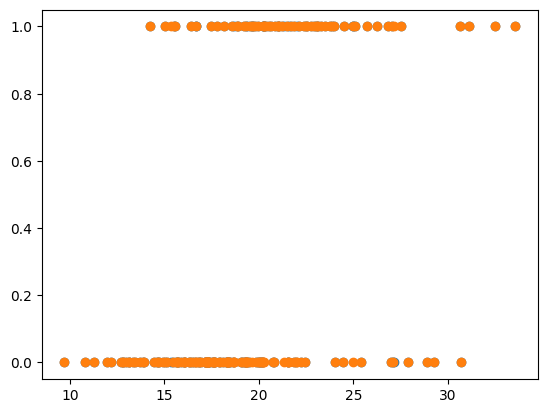

In [32]:
plt.scatter(df_features_test["texture_mean"], df_target_test)
plt.scatter(df_features_test["texture_mean"], pred)

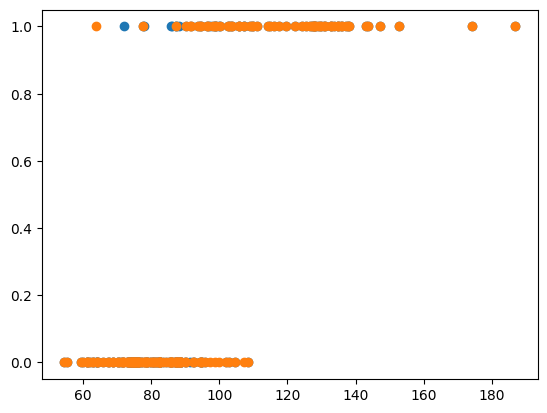

In [33]:
plt.scatter(df_features_test["perimeter_mean"], df_target_test)
plt.scatter(df_features_test["perimeter_mean"], pred)

**CS7.** *Confusion Matrix:* Write a function `confusion_matrix()` that takes in:
- `ytrue`: which is the true target values
- `ypred`: which is the predicted target values
- `labels`: which is a list of the category. In the above case it will be `[1, 0]`. Put the positive case as the first element of the list. 

The function should return a dictionary containing the matrix with the following format.

|                 | predicted positive (1) | predicted negative (0) |
|-----------------|--------------------|--------------------|
| actual positive (1) | correct positive  (1, 1) | false negative (1, 0)    |
| actual negative (0) | false positive (0, 1)   | correct negative (0, 0)   |

The keys to the dictionary are the indices: `(0, 0), (0, 1), (1, 0), (1, 1)`.

You can use the following function in your code:
- `itertools.product()`: this is to create a combination of all the labels. 

In [34]:
import itertools
def confusion_matrix(ytrue: np.ndarray, 
                     ypred: np.ndarray, 
                     labels: list[int]) -> dict[tuple[int, int], int]:
    output: dict[tuple[int, int], int] = {}

    # create the combination of the keys to the result dict 
    # for example, if a 2x2 Conf Matrix, then we need the keys: (0,0), (0,1), (1,0), (1,1)
    # use a library to do this
    keys: itertools.product[tuple] = itertools.product(labels, repeat = 2) # performs cartesian product on the given labels
    # for example if labels is 0,1,2 (e.g: cat, dog fish), then it will output (0,0), (0,1), (0,2) ... (2,0), (2,1), (2,2)

    for k in keys:
        output[k] = 0  # init the dictionary

    # example:
    # ytrue is [[0] [0] [1] [0]]
    # ypred is [[0] [1] [0] [0]]
    # so ytrue[0,0] is 0, and ypred[0,0] is 0 ---> this should +1 to output[(0,0)]
    # so we use the ELEMENT of ytrue,ypred at that index as the KEY to output dict, and simply increment by 1
    for idx in range(ytrue.shape[0]): # generate idx from 0 to the length of the dataset - 1
        output[(ytrue[idx,0], ypred[idx,0])] += 1
    
    return output


In [35]:
result: dict[tuple[int, int], int] = confusion_matrix(df_target_test.values, pred, [1,0])
print(result)
assert result == {(0, 0): 99, (0, 1): 2, (1, 0): 10, (1, 1): 59} 

{(1, 1): 59, (1, 0): 10, (0, 1): 2, (0, 0): 99}


**CS8.** *Metrics:* Write a function `calc_accuracy()` that takes in a Confusion Matrix array and output a dictionary with the following keys and values:
- `accuracy`: total number of correct predictions / total number of records
- `sensitivity`: total correct positive cases / total positive cases
- `specificity`: total true negatives / total negative cases
- `precision`: total  of correct positive cases / total predicted positive cases

In [36]:
# can only be used on 2x2 Conf Matrix
def calc_accuracy(cm: dict[tuple[int, int], int]) -> dict[str, float]:
    negneg:int = cm[(0,0)]
    pospos:int = cm[(1,1)]
    negpos:int = cm[(0,1)]
    posneg:int = cm[(1,0)]
    accuracy:float = (negneg + pospos) / np.sum(list(cm.values()))
    sensitivity:float = pospos / (pospos + posneg) # true pred pos / actual pos
    specificity:float = negneg / (negpos + negneg) # true pred neg / actual neg
    precision: float = pospos / (pospos + negpos) # true pred pos / pred pos
    result: dict[str, float] = {
       'accuracy':  accuracy,
       'sensitivity': sensitivity,
       'specificity': specificity,
       'precision': precision
    }
    return result
    


In [37]:
ans: dict[str, float] = calc_accuracy(result)
# print(ans)
expected = {'accuracy': 0.9294, 'sensitivity': 0.8551, 'specificity': 0.9802, 'precision': 0.9672}
assert np.isclose(ans['accuracy'], expected['accuracy'], rtol=1e-3)
assert np.isclose(ans['sensitivity'], expected['sensitivity'], rtol=1e-3)
assert np.isclose(ans['specificity'], expected['specificity'], rtol=1e-3)
assert np.isclose(ans['precision'], expected['precision'], rtol=1e-3)
 

**CS9.** *Optional:* Redo the above tasks using Scikit Learn libraries. You will need to use the following:
- [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)
- [confusion_matrix](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix as cm_sk

ModuleNotFoundError: No module named 'sklearn'

In [ ]:
columns: list[str] = ["radius_mean", "texture_mean", "perimeter_mean", "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean"]
# get the features and the columns
# df_features, df_target = None

# replace target values with 0 and 1
# df_target: pd.DataFrame = None

### BEGIN SOLUTION
# get the features and the targets
df_features, df_target = get_features_targets(df, columns, ["diagnosis"])

# replace target values with 0 and 1
df_target: pd.DataFrame = replace_target(df_target, "diagnosis", {'M':1, 'B':0})
### END SOLUTION

In [ ]:
# split data set using random_state = 100 and 30% test size
# df_features_train, df_features_test, df_target_train, df_target_test = None, None, None, None

# change feature to numpy array and append column of 1s
# feature: np.ndarray = None

# change target to numpy array
# target: np.ndarray = None

# this is to ensure it is either 0 or 1

### BEGIN SOLUTION
df_features_train, df_features_test, df_target_train, df_target_test = train_test_split(df_features, df_target, random_state=100, test_size=0.3)

target: np.ndarray = df_target_train.to_numpy()
### END SOLUTION
target: np.ndarray = target.astype(int) 
print(target.shape)

In [ ]:
# create LogisticRegression object instance, use newton-cg solver
# model: LogisticRegression = None

# build model
# pass

# get predicted value
# pred: np.ndarray = None

### BEGIN SOLUTION
skmodel: LogisticRegression = LogisticRegression(solver='newton-cg')

skmodel.fit(df_features_train.to_numpy(), target.flatten())
pred: np.ndarray = skmodel.predict(df_features_test.to_numpy())
### END SOLUTION 

In [ ]:
# calculate confusion matrix
# cm: dict[tuple[int, int], int] = None

### BEGIN SOLUTION
cm: dict[tuple[int, int], int] = cm_sk(df_target_test.to_numpy().astype(int), pred, labels=[1, 0])
### END SOLUTION


In [ ]:
expected: np.ndarray = np.array([[58,  11], [6, 96]])
assert np.array(cm == expected).all()

In [ ]:
plt.scatter(df_features_test["radius_mean"], df_target_test)
plt.scatter(df_features_test["radius_mean"], pred)

In [ ]:
plt.scatter(df_features_test["texture_mean"], df_target_test)
plt.scatter(df_features_test["texture_mean"], pred)

In [ ]:
plt.scatter(df_features_test["perimeter_mean"], df_target_test)
plt.scatter(df_features_test["perimeter_mean"], pred)